# Invoice processing – analysis notebook

## 1. What this is

Pyökkipaja Oy, a fictional Lahti furniture manufacturer, receives 198 PDF invoices across
2025 from suppliers its e-invoicing network does not reach. A Sonnet subagent reads each PDF
and returns a structured record; an overseer watches the accepted parses per supplier and,
once a supplier has sent enough structurally consistent invoices, writes a plain deterministic
parser that replaces the model at run time. Repeat suppliers migrate to free parsing one at a
time, one-off suppliers stay on the model by design, and one supplier's mid-year template
redesign forces its parser to fail loudly and relearn. Every document is synthetic, generated
by seeded Python against a held-out answer key that marks both paths' output, and every result
below is read off run artefacts rather than restated from memory.

This notebook reads only `data/manifest.json`, `data/master_data.json`,
`data/runs/stream_events.json`, `data/runs/parse_agent_log.json` and
`data/runs/evaluation.json` – every number that follows is computed from those five files at
execution time, not typed in as a result. **It never opens `data/answer_key/`**. Marking
against the key already happened once, in `evaluate.py`, and re-deriving it here would be
re-marking the exam with the answer sheet open. Full framing lives in `design/design.md`, the
run's findings in `data/runs/report.md`. To reproduce this notebook from the project root:

```
jupyter nbconvert --to notebook --execute --inplace notebooks/invoice_processing_analysis.ipynb
```

In [1]:
# Standard tooling. Seeds are irrelevant here – this notebook reads recorded run
# artefacts rather than generating anything – but every number is loaded live below.
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime
import json

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import pandas as pd

print("Libraries loaded.", flush=True)

Libraries loaded.


In [2]:
# --- Robust project-root resolution -------------------------------------------------
# nbconvert executes this notebook with Path.cwd() == the notebooks/ folder, but the
# same cell also has to work if someone re-runs it from the project root by hand. Walk
# upward from the current working directory until data/manifest.json turns up.

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "manifest.json").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root (a directory containing data/manifest.json) "
        f"starting from {start}. Run this notebook from within the '03 Invoices' project tree."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data"
RUNS_DIR = DATA_DIR / "runs"
print(f"Project root resolved to: {PROJECT_ROOT}", flush=True)

Project root resolved to: C:\Users\luigi\Dropbox\Archivio famiglia\Hapax\Case Studies\03 Invoices


In [3]:
# --- Load every input artefact this notebook is allowed to touch --------------------
# Deliberately absent from this list: anything under data/answer_key/. Marking against
# the key already happened once, in evaluate.py, whose output is evaluation.json below.

def load_json(path: Path):
    print(f"Loading {path.relative_to(PROJECT_ROOT)} ...", flush=True)
    try:
        with path.open(encoding="utf-8") as f:
            return json.load(f)
    except (OSError, json.JSONDecodeError) as e:
        raise RuntimeError(f"Could not read required artefact {path}: {e}") from e


manifest = load_json(DATA_DIR / "manifest.json")
master_data = load_json(DATA_DIR / "master_data.json")
stream_events = load_json(RUNS_DIR / "stream_events.json")
parse_agent_log = load_json(RUNS_DIR / "parse_agent_log.json")
evaluation = load_json(RUNS_DIR / "evaluation.json")

print("\nAll five input artefacts loaded.", flush=True)

Loading data\manifest.json ...


Loading data\master_data.json ...


Loading data\runs\stream_events.json ...


Loading data\runs\parse_agent_log.json ...


Loading data\runs\evaluation.json ...



All five input artefacts loaded.


In [4]:
# --- Shared chart styling (validated Hapax chart palette, 3 Jul 2026) ---------------
# wine / indigo / gold are the three identity hues; grey is for context/annotations
# only; beige is a fill colour; ink is the one text colour; FBFAF5 is the page
# background. At most three identity hues per chart, one y-axis per chart.
WINE = "#A8352A"
INDIGO = "#41529E"
GOLD = "#B68A2C"
GREY = "#665E58"
BEIGE = "#EFE5CE"
INK = "#1A1410"
BACKGROUND = "#FBFAF5"

plt.rcParams.update({
    "figure.facecolor": BACKGROUND,
    "axes.facecolor": BACKGROUND,
    "savefig.facecolor": BACKGROUND,
    "text.color": INK,
    "axes.edgecolor": INK,
    "axes.labelcolor": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.titlelocation": "left",
})


def style_axes(ax):
    """Thin marks, no chart junk: drop the top/right spines, keep everything else
    restrained. Applied to every figure in this notebook."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(INK)
    ax.spines["bottom"].set_color(INK)
    ax.tick_params(colors=INK, length=3)
    return ax


print("Palette and style helpers ready.", flush=True)

Palette and style helpers ready.


## 2. The corpus at a glance

198 documents, calendar 2025, 26 suppliers, 12 months. Every document belongs to one of five
pre-registered classes (design.md §4), each with a designed outcome the rest of this notebook
scores actual results against:

| Class | Meaning | Count (of 198) |
|---|---|---|
| **R** – routine | Repeat-supplier invoices in the supplier's standard layout | 165 |
| **O** – one-off | Suppliers seen once or twice, below any learning threshold | 20 |
| **T** – template redesign | Supplier S8's post-redesign invoices (from 1 Aug) | 8 |
| **F** – fail-and-recover | Planted breakers: a credit note, a fuel-surcharge line, a two-page attachment | 4 |
| **S** – silent error | One invoice with quantity and price transposed at the source | 1 |

The corpus also spans five locale/format variants (`fi`, `fi_compact`, `de`, `sv`, `en` –
`config.py`), rooted in the countries computed below.

In [5]:
# Live counts from the manifest – these must match the design-doc class table above,
# and the assert below is the notebook's live guarantee that they still do.
class_counts = manifest["class_counts"]
month_counts = manifest["month_counts"]
countries = sorted({s["country"] for s in master_data["suppliers"]})

print("Documents:      ", manifest["document_count"])
print("Suppliers:      ", len(master_data["suppliers"]))
print("Months:         ", len(month_counts))
print("Countries:      ", countries)
print("Class counts:   ", class_counts)

expected_class_counts = {"R": 165, "O": 20, "T": 8, "F": 4, "S": 1}
assert manifest["document_count"] == 198, f"document_count drifted: {manifest['document_count']}"
assert len(master_data["suppliers"]) == 26, f"supplier count drifted: {len(master_data['suppliers'])}"
assert len(month_counts) == 12, f"month count drifted: {len(month_counts)}"
assert len(countries) == 5, f"country count drifted: {countries}"
assert class_counts == expected_class_counts, (
    f"Class counts no longer match design.md §4: {class_counts} != {expected_class_counts}"
)

print("\nAssert passed: 198 documents, 26 suppliers, 12 months, 5 countries, "
      "class counts R/O/T/F/S = 165/20/8/4/1.")

Documents:       198
Suppliers:       26
Months:          12
Countries:       ['DE', 'EE', 'FI', 'IE', 'SE']
Class counts:    {'R': 165, 'O': 20, 'T': 8, 'F': 4, 'S': 1}

Assert passed: 198 documents, 26 suppliers, 12 months, 5 countries, class counts R/O/T/F/S = 165/20/8/4/1.


## 3. The stream replay

`router.py` replays the 198 documents in true issue-date order and assigns each one of four
paths: **llm-discovery** (a repeat supplier's first several invoices, before its parser
exists), **llm-oneoff** (a one-off supplier, permanently), **llm-fallback** (a deterministic
parser exists but this document fails its validation and falls back), and **deterministic**
(a live parser handles it, no model call). The counts below are asserted against the
pre-registered totals before anything is plotted.

In [6]:
doc_events = [e for e in stream_events if "doc_id" in e]
parser_birth_events = [e for e in stream_events if e.get("event") == "parser_born"]
assert len(doc_events) == 198, f"expected 198 document events in the stream, found {len(doc_events)}"

path_counts = dict(Counter(e["path"] for e in doc_events))
print("Path counts:", path_counts)

expected_path_counts = {"deterministic": 117, "llm-discovery": 48, "llm-fallback": 13, "llm-oneoff": 20}
assert path_counts == expected_path_counts, (
    f"Stream path counts no longer match: {path_counts} != {expected_path_counts}"
)
print("\nAssert passed: stream path counts are deterministic / llm-discovery / llm-fallback / "
      "llm-oneoff = 117 / 48 / 13 / 20.")

Path counts: {'llm-discovery': 48, 'llm-oneoff': 20, 'deterministic': 117, 'llm-fallback': 13}

Assert passed: stream path counts are deterministic / llm-discovery / llm-fallback / llm-oneoff = 117 / 48 / 13 / 20.


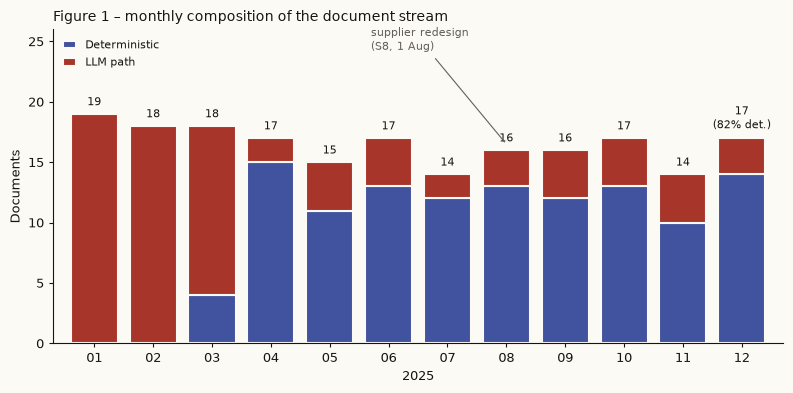


December: 17 documents, 14 deterministic (82.4%).


In [7]:
# --- Figure 1: monthly composition of the document stream ---------------------------
monthly = defaultdict(lambda: {"deterministic": 0, "llm": 0})
for e in doc_events:
    month = e["date"][:7]
    if e["path"] == "deterministic":
        monthly[month]["deterministic"] += 1
    else:
        monthly[month]["llm"] += 1

months_sorted = sorted(monthly.keys())
det_counts = [monthly[m]["deterministic"] for m in months_sorted]
llm_counts = [monthly[m]["llm"] for m in months_sorted]
totals = [d + l for d, l in zip(det_counts, llm_counts)]

fig, ax = plt.subplots(figsize=(8, 4))
x = list(range(len(months_sorted)))

# 2px white (background-coloured) gaps between segments and between bars.
ax.bar(x, det_counts, color=INDIGO, edgecolor=BACKGROUND, linewidth=1.5, label="Deterministic")
ax.bar(x, llm_counts, bottom=det_counts, color=WINE, edgecolor=BACKGROUND, linewidth=1.5,
       label="LLM path")

# Direct labels on totals only – no per-segment labels. December also carries its
# deterministic share, folded into the same total label rather than a second text box
# (which would run past the right-hand edge of the last bar).
dec_idx = months_sorted.index("2025-12")
dec_share = det_counts[dec_idx] / totals[dec_idx]
for i, total in enumerate(totals):
    label = str(total) if i != dec_idx else f"{total}\n({dec_share:.0%} det.)"
    ax.text(i, total + 0.5, label, ha="center", va="bottom", fontsize=8, color=INK)

ax.set_xlim(-0.7, len(months_sorted) - 0.3)
ax.set_xticks(x)
ax.set_xticklabels([m[5:7] for m in months_sorted])
ax.set_xlabel("2025")
ax.set_ylabel("Documents")
ax.set_ylim(0, max(totals) + 7)
ax.legend(frameon=False, loc="upper left", fontsize=8, handlelength=1.2)

# Grey annotation: August (the S8 template redesign).
aug_idx = months_sorted.index("2025-08")
ax.annotate("supplier redesign\n(S8, 1 Aug)", xy=(aug_idx, totals[aug_idx] + 0.5),
            xytext=(aug_idx - 2.3, max(totals) + 5.3), fontsize=8, color=GREY,
            arrowprops=dict(arrowstyle="-", color=GREY, lw=0.8))

style_axes(ax)
ax.set_title("Figure 1 – monthly composition of the document stream", loc="left")
plt.tight_layout()
plt.show()

print(f"\nDecember: {totals[dec_idx]} documents, {det_counts[dec_idx]} deterministic "
      f"({dec_share:.1%}).")

## 4. Parser births and the re-learning arc

Supplier S8 redesigns its invoicing software on 1 August 2025 (`config.py` `T_CUTOVER_DATE`,
same legal identity, new layout). Its live parser starts failing loudly on the new layout –
exactly the fail-loud posture the overseer brief mandates, not a silent misread. The
post-redesign invoices fall back to the LLM path while the overseer collects fresh examples of
the new layout, under the identical accepted-parses threshold as first learning. Once enough
have accumulated, it writes a second parser, `parser_s8v2` – which, per the process notes in
`report.md`, uses the invoice-number series format as a hard discriminator against the old
layout – and the supplier's documents resume parsing deterministically before the year is out.

parser supplier birth_date  documents_seen_before_birth
    s1       s1 2025-02-27                            6
    s2       s2 2025-03-17                            6
    s3       s3 2025-03-21                            6
    s4       s4 2025-03-31                            6
    s5       s5 2025-03-18                            6
    s6       s6 2025-03-31                            6
    s7       s7 2025-06-30                            6
    s8       s8 2025-03-17                            6
  s8v2       s8 2025-10-28                            6


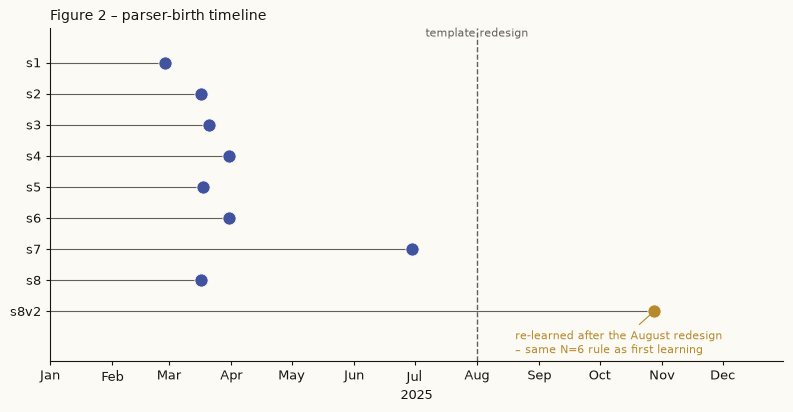


Slowest first-time learner: parser_s7, born 30 June 2025 – supplier s7 invoices monthly, so accumulating enough consistent examples simply takes longer in calendar time.


In [8]:
# --- Figure 2: parser-birth timeline -------------------------------------------------
births = evaluation["shares"]["parser_birth_timeline"]
births_table = pd.DataFrame(births).sort_values("parser").reset_index(drop=True)
births_table["birth_date"] = pd.to_datetime(births_table["birth_date"])
print(births_table[["parser", "supplier", "birth_date", "documents_seen_before_birth"]]
      .to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.2))
parser_names = list(births_table["parser"])
n_parsers = len(parser_names)
# Largest y at the top (s1) down to y=0 at the bottom (s8v2) – built this way round
# rather than via invert_yaxis(), so "above the top row" / "below the bottom row" stay
# intuitive (y > n_parsers-1, y < 0) when placing the annotations below.
y_positions = list(range(n_parsers - 1, -1, -1))

for y, row in zip(y_positions, births_table.itertuples()):
    is_relearned = row.parser.endswith("v2")
    marker_color = GOLD if is_relearned else INDIGO
    # thin baseline from the start of the year to birth, showing time spent LLM-only
    ax.plot([datetime(2025, 1, 1), row.birth_date], [y, y], color=GREY, lw=0.8, zorder=1)
    ax.scatter([row.birth_date], [y], s=90, color=marker_color, zorder=3,
               edgecolor=BACKGROUND, linewidth=0.6)

ax.set_yticks(y_positions)
ax.set_yticklabels(parser_names)
ax.set_ylim(-1.6, n_parsers - 1 + 1.1)
ax.set_xlim(datetime(2025, 1, 1), datetime(2025, 12, 31))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_xlabel("2025")

# Redesign cutover, a design constant (config.py T_CUTOVER_DATE), not a measured result.
redesign_date = datetime(2025, 8, 1)
ax.axvline(redesign_date, color=GREY, lw=1, linestyle="--", zorder=0)
ax.annotate("template redesign", xy=(redesign_date, n_parsers - 1 + 0.75),
            ha="center", va="bottom", fontsize=8, color=GREY)

s8v2_row = births_table[births_table["parser"] == "s8v2"].iloc[0]
s8v2_y = y_positions[parser_names.index("s8v2")]
ax.annotate("re-learned after the August redesign\n– same N=6 rule as first learning",
            xy=(s8v2_row["birth_date"], s8v2_y),
            xytext=(datetime(2025, 8, 20), s8v2_y - 1.35),
            fontsize=8, color=GOLD,
            arrowprops=dict(arrowstyle="-", color=GOLD, lw=0.8))

style_axes(ax)
ax.set_title("Figure 2 – parser-birth timeline", loc="left")
plt.tight_layout()
plt.show()

s7_row = births_table[births_table["parser"] == "s7"].iloc[0]
print(f"\nSlowest first-time learner: parser_{s7_row['parser']}, born "
      f"{s7_row['birth_date'].strftime('%d %B %Y')} – supplier s7 invoices monthly, "
      f"so accumulating enough consistent examples simply takes longer in calendar time.")

## 5. Accuracy against the answer key

`evaluate.py` is the only script in this pipeline that opens `data/answer_key/`; this notebook
reads its output, `evaluation.json`, and never the key itself.

In [9]:
acc = evaluation["accuracy"]

accuracy_rows = []
for key, label in [("llm", "LLM (Sonnet subagents, vision reads)"),
                    ("deterministic", "Deterministic (generated parsers)"),
                    ("overall", "Overall")]:
    a = acc[key]
    accuracy_rows.append({
        "Path": label,
        "Documents": a["docs"],
        "Fields": a["fields"],
        "Wrong (incl. S)": a["wrong_including_s"],
        "Accuracy (incl. S)": f'{a["field_accuracy_including_s"]:.4%}',
        "Accuracy (excl. S)": f'{a["field_accuracy_excluding_s"]:.4%}',
    })
accuracy_table = pd.DataFrame(accuracy_rows)
accuracy_table

,Path,Documents,Fields,Wrong (incl. S),Accuracy (incl. S),Accuracy (excl. S)
0,"LLM (Sonnet subagents, vision reads)",81,5427,0,100.0000%,100.0000%
1,Deterministic (generated parsers),117,8223,2,99.9757%,100.0000%
2,Overall,198,13650,2,99.9853%,100.0000%


In [10]:
# Live asserts on the headline accuracy figures.
assert acc["llm"]["fields"] == 5427, f"LLM field count drifted: {acc['llm']['fields']}"
assert acc["llm"]["field_accuracy_including_s"] == 1.0, (
    f"LLM accuracy is no longer 100%: {acc['llm']['field_accuracy_including_s']}"
)
assert acc["overall"]["wrong_including_s"] == 2, (
    f"Overall wrong-value count drifted from 2: {acc['overall']['wrong_including_s']}"
)
assert acc["deterministic"]["field_accuracy_excluding_s"] == 1.0, (
    "Deterministic accuracy excluding the S document is no longer 100%: "
    f"{acc['deterministic']['field_accuracy_excluding_s']}"
)

s_document = evaluation["s_document"]
assert len(s_document["designed_mismatch_fields"]) == 2, (
    f"S document mismatch field count drifted: {len(s_document['designed_mismatch_fields'])}"
)
assert s_document["path"] == "deterministic"

print("Assert passed: LLM path 100.0000% across 5,427 fields; the only "
      f"{acc['overall']['wrong_including_s']} wrong values in the entire pipeline both belong "
      "to the S document; deterministic accuracy excluding S is 100%.")

Assert passed: LLM path 100.0000% across 5,427 fields; the only 2 wrong values in the entire pipeline both belong to the S document; deterministic accuracy excluding S is 100%.


### The S-document panel

One document (below) has its quantity and unit price transposed **at the source**, printed as
a larger quantity at a correspondingly lower unit price than what was actually ordered (exact
values in the code cell below). The line total, every arithmetic check and every identifier
are internally perfect, so both the LLM and the deterministic path read the document faithfully
and both are therefore "wrong" in exactly the same way. No document-reading system, however
good, can recover a fact the document itself misstates, which makes this a **designed
mismatch, not an extraction error**. What catches it in production is not better parsing but a
standard **three-way match** (purchase order – goods receipt – invoice), reconciling the
quantity and price actually ordered against what the invoice claims, deliberately kept outside
this router's own validation (design.md §7) so that this document's outcome is not accidentally
erased by the very check meant to motivate it.

In [11]:
print(f"S document: {s_document['doc_id']} (path: {s_document['path']})\n")
for field in s_document["designed_mismatch_fields"]:
    print(f"  {field['field']:20s} parsed = {field['parsed']:>8}   truth = {field['truth']:>8}")
print(f"\nNote: {s_document['note']}")

S document: 2025-11_s2_03 (path: deterministic)

  lines[0].quantity    parsed =       50   truth =        2
  lines[0].unit_price  parsed =     2.00   truth =    50.00

Note: The S document's quantity/unit_price are transposed at the source (printed 50 x EUR2.00 where the order was 2 x EUR50.00); neither path can catch it from the document alone. Excluded from the error counts and reported here separately (design.md §4).


## 6. The designed-outcome scorecard

Every document was assigned to a class before the pipeline ever ran (design.md §4); this table
compares what was designed against what actually happened, path by path.

In [12]:
scorecard = evaluation["designed_outcome_scorecard"]

scorecard_rows = []
for cls in ["R", "O", "T", "F", "S"]:
    entry = scorecard[cls]
    verdict = "As designed" if entry["actual"] == entry["designed"] else "Deviation"
    scorecard_rows.append({
        "Class": cls,
        "Designed": entry["designed"],
        "Actual": entry["actual"],
        "Verdict": verdict,
    })
scorecard_table = pd.DataFrame(scorecard_rows)
scorecard_table

,Class,Designed,Actual,Verdict
0,R,"{'llm-discovery': 48, 'deterministic': 117}","{'llm-discovery': 48, 'deterministic': 113, 'l...",Deviation
1,O,{'llm-oneoff': 20},{'llm-oneoff': 20},As designed
2,T,"{'llm-fallback': 6, 'deterministic': 2}","{'llm-fallback': 6, 'deterministic': 2}",As designed
3,F,{'llm-fallback': 4},"{'deterministic': 1, 'llm-fallback': 3}",Deviation
4,S,{'deterministic': 1},{'deterministic': 1},As designed


In [13]:
deviations = evaluation["deviations_from_design"]
print("Deviations recorded in evaluation.json:")
for d in deviations:
    print(" -", d)

# report.md froze these exact four class-path deviations as the honest scorecard. This
# assert checks evaluation.json (the live artefact) still agrees with that written record.
expected_deviations = {
    "class F, path deterministic: designed 0, actual 1",
    "class F, path llm-fallback: designed 4, actual 3",
    "class R, path deterministic: designed 117, actual 113",
    "class R, path llm-fallback: designed 0, actual 4",
}
assert set(deviations) == expected_deviations and len(deviations) == 4, (
    f"Deviation list no longer matches report.md's frozen scorecard: {deviations}"
)
print("\nAssert passed: exactly the four class-path deviations recorded in report.md, no others.")

Deviations recorded in evaluation.json:
 - class F, path deterministic: designed 0, actual 1
 - class F, path llm-fallback: designed 4, actual 3
 - class R, path deterministic: designed 117, actual 113
 - class R, path llm-fallback: designed 0, actual 4

Assert passed: exactly the four class-path deviations recorded in report.md, no others.


Both deviations are rendered honestly rather than smoothed over. **F is defeated once** – one
of the four planted breakers, a fuel-surcharge line with no product code on a freight invoice,
was supposed to fail validation and fall back to the LLM, but `parser_s6`'s dynamic column
derivation treats the unfamiliar line as ordinary data and parses it correctly anyway.
Pre-registering the designed outcome is what makes a parser turning out to be *better* than
planned into a visible, auditable fact rather than a silent non-event. **R loses four documents
to an unplanned fail-loud event**, because the corpus naturally contains some two-page invoices;
where an induction set happened to include one the resulting parser generalises to
continuation pages, and where it did not, the parser asserts single-page and refuses rather than
guesses. Four documents therefore fall back to the LLM unplanned – the strongest unscripted
illustration of the design's central safety claim, that what the parser has not seen, it does
not invent.

## 7. Costs – labelled estimates

Accuracy above is exact, marked against a held-out key. Cost is not, because the LLM path ran
as Claude Code subagents inside the existing subscription (method B, the portfolio's cost-accounting
decision), so every figure below is **measured subagent token usage** – harness-inclusive, an
upper bound on what a purpose-built extractor would use – **priced at published list rates**.
The pricing reference this pipeline used is quoted verbatim below rather than restated.

In [14]:
pricing = parse_agent_log["pricing_reference"]
print(f"Source: {pricing['source']}")
print(f"Model class: {pricing['model_class']}, as of {pricing['as_of']}")
print(f"List price: ${pricing['usd_per_mtok_input']:.0f} / ${pricing['usd_per_mtok_output']:.0f} "
      "per MTok (input / output)\n")
print("Note (quoted verbatim from parse_agent_log.json):")
print(f"  {pricing['note']}")

Source: Anthropic published list prices, verified via the claude-api reference skill on the run date


Model class: Claude Sonnet tier (claude-sonnet-5), as of 2026-07-03
List price: $3 / $15 per MTok (input / output)

Note (quoted verbatim from parse_agent_log.json):
  Standard list price, used for comparability with Case 2's estimates and consistent with the upper-bound posture of method B. Introductory Sonnet 5 pricing ($2/$10 per MTok) was in force on the run date (through 2026-08-31) and would reduce every cost estimate by a further ~33%.


In [15]:
# Measured token totals, split by wave, computed live from parse_agent_log.json.
wave_tokens = {}
for wave in parse_agent_log["waves"]:
    wave_tokens[wave["wave"]] = sum(b["subagent_tokens"] for b in wave["batches"])

parse_tokens = wave_tokens.get("discovery_wave", 0) + wave_tokens.get("oneoff_wave", 0) \
    + wave_tokens.get("fallback_wave", 0)
overseer_tokens = wave_tokens.get("overseer_generation_wave", 0)
total_tokens = parse_tokens + overseer_tokens

print("Measured subagent tokens by wave:")
for wave_name, tokens in wave_tokens.items():
    print(f"  {wave_name:26s} {tokens:>10,}")
print(f"\n  {'total':26s} {total_tokens:>10,}")
print(f"\nOverseer share of total tokens: {overseer_tokens / total_tokens:.1%}")

n_llm_parses = acc["llm"]["docs"]
print(f"Mean tokens per LLM parse (measured): {parse_tokens / n_llm_parses:,.0f} "
      f"across {n_llm_parses} documents")

Measured subagent tokens by wave:
  discovery_wave                456,037
  oneoff_wave                   185,897
  overseer_generation_wave    1,066,271
  fallback_wave                 176,934

  total                       1,885,139

Overseer share of total tokens: 56.6%
Mean tokens per LLM parse (measured): 10,109 across 81 documents


In [16]:
cost_estimates = evaluation["cost_estimates_block"]["cost_estimates"]

cost_rows = [
    {"Quantity": "Hybrid pipeline, year 1 (parses + parser generation)",
     "Floor (all-input)": cost_estimates["hybrid"]["floor_all_input_usd"],
     "Central (85/15)": cost_estimates["hybrid"]["central_85_15_usd"],
     "Ceiling (all-output)": cost_estimates["hybrid"]["ceiling_all_output_usd"]},
    {"Quantity": "All-LLM counterfactual (198 x mean parse tokens)",
     "Floor (all-input)": cost_estimates["counterfactual_all_llm"]["floor_all_input_usd"],
     "Central (85/15)": cost_estimates["counterfactual_all_llm"]["central_85_15_usd"],
     "Ceiling (all-output)": cost_estimates["counterfactual_all_llm"]["ceiling_all_output_usd"]},
]
cost_table = pd.DataFrame(cost_rows)
print("All figures below are ESTIMATES (method B).\n")
cost_table

All figures below are ESTIMATES (method B).



,Quantity,Floor (all-input),Central (85/15),Ceiling (all-output)
0,"Hybrid pipeline, year 1 (parses + parser gener...",5.66,9.05,28.28
1,All-LLM counterfactual (198 x mean parse tokens),6.01,9.61,30.03


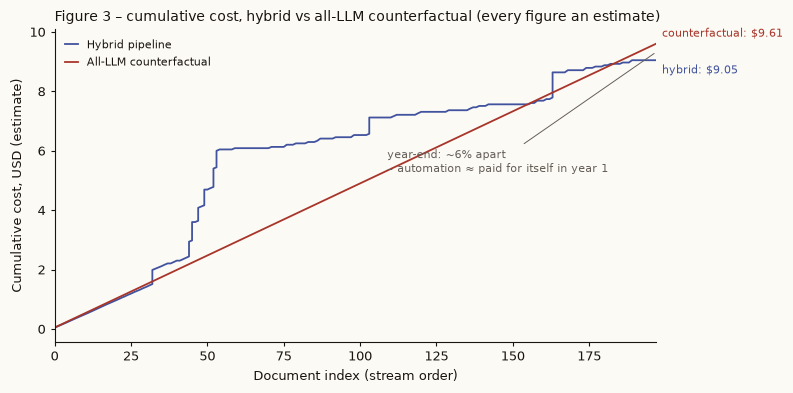


Year-1 saving (central estimate): $0.56 (5.8% of the counterfactual).


In [17]:
# --- Figure 3: cumulative cost, hybrid vs all-LLM counterfactual --------------------
cost_curve = evaluation["cost_estimates_block"]["docs_cost_curve"]

x_hybrid, y_hybrid = [], []
for entry in cost_curve:
    x_hybrid.append(entry["idx"] if "doc_id" in entry else entry["stream_index"])
    y_hybrid.append(entry["cum_hybrid_usd_est"])

n_docs = len(doc_events)
cf_central = cost_estimates["counterfactual_all_llm"]["central_85_15_usd"]
x_counterfactual = list(range(n_docs))
y_counterfactual = [(i + 1) / n_docs * cf_central for i in x_counterfactual]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_hybrid, y_hybrid, color=INDIGO, lw=1.3, label="Hybrid pipeline")
ax.plot(x_counterfactual, y_counterfactual, color=WINE, lw=1.3, label="All-LLM counterfactual")

ax.set_xlabel("Document index (stream order)")
ax.set_ylabel("Cumulative cost, USD (estimate)")
ax.set_xlim(0, n_docs - 1)

# Direct labels at line ends.
ax.annotate(f"hybrid: ${y_hybrid[-1]:.2f}", xy=(x_hybrid[-1], y_hybrid[-1]),
            xytext=(4, -3), textcoords="offset points", fontsize=8, color=INDIGO, va="top")
ax.annotate(f"counterfactual: ${y_counterfactual[-1]:.2f}",
            xy=(x_counterfactual[-1], y_counterfactual[-1]),
            xytext=(4, 3), textcoords="offset points", fontsize=8, color=WINE, va="bottom")

saving_share = 1 - y_hybrid[-1] / y_counterfactual[-1]
ax.annotate(f"year-end: ~{saving_share:.0%} apart\n– automation ≈ paid for itself in year 1",
            xy=(n_docs - 1, (y_hybrid[-1] + y_counterfactual[-1]) / 2),
            xytext=(n_docs * 0.55, y_counterfactual[-1] * 0.55),
            fontsize=8, color=GREY, ha="left",
            arrowprops=dict(arrowstyle="-", color=GREY, lw=0.7))

style_axes(ax)
ax.legend(frameon=False, loc="upper left", fontsize=8, handlelength=1.2)
ax.set_title("Figure 3 – cumulative cost, hybrid vs all-LLM counterfactual (every figure an estimate)",
             loc="left")
plt.tight_layout()
plt.show()

print(f"\nYear-1 saving (central estimate): ${y_counterfactual[-1] - y_hybrid[-1]:.2f} "
      f"({saving_share:.1%} of the counterfactual).")

The year-1 saving above is real but modest, and it is not the exhibit. **The parsers are
durable artefacts.** The overseer's one-off cost was spent once, in year 1, and every parser it
produced keeps working for free afterwards. The honest version of this story is what
happens if the same stream repeats in year 2, once every parser already exists – computed
below from the same per-document means used above and labelled as an extrapolation, not a
new measurement.

In [18]:
# --- Year-2 amortisation (extrapolation, not a measurement) -------------------------
# In a repeat of this stream with every parser already in place, the LLM path would carry
# only documents that never reach the re-learning threshold in the first place: the one-off
# tail (always below threshold, by design) and the fallbacks that recur every year because
# they are structural (a two-page layout a parser was never induced on; a planted content
# pattern a parser's validation was never built to accept) rather than one-off events like
# S8's template redesign, whose relearning is a single occurrence, not an annual cost.
oneoff_doc_ids, recurring_fallback_doc_ids = [], []
for wave in parse_agent_log["waves"]:
    if wave["wave"] == "oneoff_wave":
        for batch in wave["batches"]:
            oneoff_doc_ids += batch["doc_ids"]
    if wave["wave"] == "fallback_wave":
        for batch in wave["batches"]:
            if batch["batch"] != "T":  # T is the one-off redesign relearning, excluded here
                recurring_fallback_doc_ids += batch["doc_ids"]

n_recurring_docs = len(oneoff_doc_ids) + len(recurring_fallback_doc_ids)
mean_tokens = cost_estimates["mean_tokens_per_parsed_document_measured"]
blended_rate_per_mtok = (0.85 * pricing["usd_per_mtok_input"] + 0.15 * pricing["usd_per_mtok_output"])

year2_hybrid_cost = n_recurring_docs * mean_tokens * blended_rate_per_mtok / 1e6
year2_saving_share = 1 - year2_hybrid_cost / cf_central

print(f"Recurring LLM-path documents in a repeat year: {n_recurring_docs} "
      f"({len(oneoff_doc_ids)} one-off tail + {len(recurring_fallback_doc_ids)} structural "
      "fallbacks that never reach the re-learning threshold)")
print(f"Year-2 hybrid cost (central estimate, extrapolated): ${year2_hybrid_cost:.2f}")
print(f"Against the same all-LLM counterfactual: ${cf_central:.2f}")
print(f"Steady-state saving (extrapolation, not measured): {year2_saving_share:.0%}")

Recurring LLM-path documents in a repeat year: 27 (20 one-off tail + 7 structural fallbacks that never reach the re-learning threshold)
Year-2 hybrid cost (central estimate, extrapolated): $1.31
Against the same all-LLM counterfactual: $9.61
Steady-state saving (extrapolation, not measured): 86%


## 8. The long tail

The automation ceiling is a property of the supplier base, not of parser quality. A minority
of suppliers is repeat business at a volume worth automating; the rest is a genuine one-off
tail that the system is designed to leave on the LLM path, because automating it would cost
more than it saves. Both bars below are computed from `master_data.json` and `stream_events.json`
directly, not from any pre-aggregated figure.

Automated suppliers: 8 of 26 (30.8%) – ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8']


Volume those suppliers carry: 178 of 198 documents (89.9%)


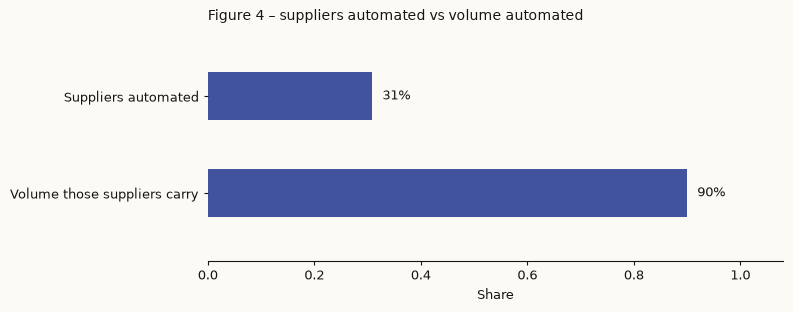


The other 69% of suppliers carry 10% of volume and stay with the model on purpose – automating any of them would cost more than it saves.


In [19]:
# --- Figure 4: suppliers automated vs volume those suppliers carry ------------------
total_suppliers = len(master_data["suppliers"])
automated_supplier_ids = {e["supplier"] for e in parser_birth_events}
total_docs = len(doc_events)
volume_automated_docs = sum(1 for e in doc_events if e["supplier"] in automated_supplier_ids)

supplier_share = len(automated_supplier_ids) / total_suppliers
volume_share = volume_automated_docs / total_docs

print(f"Automated suppliers: {len(automated_supplier_ids)} of {total_suppliers} "
      f"({supplier_share:.1%}) – {sorted(automated_supplier_ids)}")
print(f"Volume those suppliers carry: {volume_automated_docs} of {total_docs} documents "
      f"({volume_share:.1%})")

fig, ax = plt.subplots(figsize=(8, 3.2))
bars_y = [1, 0]
bars_val = [supplier_share, volume_share]
bars_label = ["Suppliers automated", "Volume those suppliers carry"]

ax.barh(bars_y, bars_val, color=INDIGO, height=0.5)
for y, val in zip(bars_y, bars_val):
    ax.text(val + 0.02, y, f"{val:.0%}", va="center", fontsize=9, color=INK)

# Category names on the y-axis itself, not as floating text – keeps them inside the
# axes area regardless of figure height, so they cannot collide with the title above.
ax.set_yticks(bars_y)
ax.set_yticklabels(bars_label, fontsize=9)
ax.tick_params(axis="y", length=0)
ax.set_ylim(-0.7, 1.7)
ax.set_xlim(0, 1.08)
ax.set_xlabel("Share")
style_axes(ax)
ax.spines["left"].set_visible(False)
ax.set_title("Figure 4 – suppliers automated vs volume automated", loc="left")
plt.tight_layout()
plt.show()

print(f"\nThe other {1 - supplier_share:.0%} of suppliers carry {1 - volume_share:.0%} of "
      "volume and stay with the model on purpose – automating any of them would cost more "
      "than it saves.")

## 9. N-threshold sensitivity (ablation)

The overseer's threshold is **N = 6** accepted, structurally consistent parses before it writes
a parser (design.md §7), chosen to keep the LLM-parse volume inside a pre-registered budget of
at most 80 documents across eight repeat suppliers. What follows is a pure-Python simulation
rather than a re-run of any agent, re-applying the birth rule to the stream order already
recorded in `stream_events.json`, varying only N, and holding fixed the documents whose outcome is
structural rather than threshold-driven – the one-off tail, the planted breakers, and the
unplanned two-page fallbacks (all identified from `manifest.json`'s class labels and each
document's actual recorded path, never from the answer key).

In [20]:
# --- Simulation setup: classify every document's role in the N-sweep ----------------
doc_class = {doc_id: info["class"] for doc_id, info in manifest["files"].items()}
doc_supplier = {e["doc_id"]: e["supplier"] for e in doc_events}
doc_idx = {e["doc_id"]: e["idx"] for e in doc_events}
doc_actual_path = {e["doc_id"]: e["path"] for e in doc_events}

s_docs = [d for d, c in doc_class.items() if c == "S"]
f_docs = [d for d, c in doc_class.items() if c == "F"]
t_docs = [d for d, c in doc_class.items() if c == "T"]
r_docs = [d for d, c in doc_class.items() if c == "R"]
o_docs = [d for d, c in doc_class.items() if c == "O"]

# F-class planted breakers: each keeps its own actual outcome regardless of N – a
# validation failure caused by unfamiliar content, not by how many examples the
# overseer had seen.
f_fallback = [d for d in f_docs if doc_actual_path[d] == "llm-fallback"]
f_deterministic = [d for d in f_docs if doc_actual_path[d] == "deterministic"]

# R-class documents whose actual path was llm-fallback are the unplanned two-page
# documents a single-page-only parser refuses – structural, held fixed regardless of N.
u_docs = [d for d in r_docs if doc_actual_path[d] == "llm-fallback"]
r_capturable = [d for d in r_docs if d not in u_docs]

print(f"S (always deterministic): {len(s_docs)}")
print(f"F fixed fallback: {len(f_fallback)}, F fixed deterministic: {len(f_deterministic)}")
print(f"O (always llm-oneoff, below any threshold in this range): {len(o_docs)}")
print(f"R capturable by an N-threshold parser: {len(r_capturable)} (of {len(r_docs)}; "
      f"{len(u_docs)} are structural two-page fallbacks, held fixed)")
print(f"T (redesign re-learning, re-derived per N): {len(t_docs)}")

S (always deterministic): 1
F fixed fallback: 3, F fixed deterministic: 1
O (always llm-oneoff, below any threshold in this range): 20
R capturable by an N-threshold parser: 161 (of 165; 4 are structural two-page fallbacks, held fixed)
T (redesign re-learning, re-derived per N): 8


In [21]:
def simulate(n_threshold: int) -> dict:
    """Re-apply the overseer's birth rule at a given N to the recorded stream order.
    Returns llm-path and deterministic document counts for the whole 198-document year."""
    llm_count = len(o_docs) + len(f_fallback) + len(u_docs)
    deterministic_count = len(s_docs) + len(f_deterministic)

    # Each of the 8 repeat suppliers: first N of its capturable R documents (in stream
    # order) are discovery/LLM; the rest are deterministic once the parser is live.
    by_supplier = defaultdict(list)
    for d in r_capturable:
        by_supplier[doc_supplier[d]].append(d)
    for docs in by_supplier.values():
        docs_sorted = sorted(docs, key=lambda d: doc_idx[d])
        for position, _ in enumerate(docs_sorted):
            if position < n_threshold:
                llm_count += 1
            else:
                deterministic_count += 1

    # T-class (S8's redesign): the first N are the re-learning fallback; the rest
    # deterministic once v2 is live – unless there are fewer than N left in the year,
    # in which case the parser never gets reborn before the stream ends.
    t_sorted = sorted(t_docs, key=lambda d: doc_idx[d])
    if len(t_sorted) < n_threshold:
        llm_count += len(t_sorted)
    else:
        llm_count += n_threshold
        deterministic_count += len(t_sorted) - n_threshold

    return {"n": n_threshold, "llm_parses": llm_count, "deterministic": deterministic_count,
            "deterministic_share": deterministic_count / (llm_count + deterministic_count)}


n_values = list(range(4, 11))
sweep = pd.DataFrame([simulate(n) for n in n_values])
sweep

,n,llm_parses,deterministic,deterministic_share
0,4,63,135,0.681818
1,5,72,126,0.636364
2,6,81,117,0.590909
3,7,90,108,0.545455
4,8,99,99,0.500000
5,9,107,91,0.459596
6,10,115,83,0.419192


In [22]:
# Sanity check: at the design's own N=6, the simulation must reproduce the real,
# recorded stream totals exactly – this is what makes the sweep trustworthy at other N.
sweep_at_6 = sweep[sweep["n"] == 6].iloc[0]
assert sweep_at_6["llm_parses"] == acc["llm"]["docs"], (
    f"Simulation at N=6 does not reproduce the recorded LLM-parse count: "
    f"{sweep_at_6['llm_parses']} != {acc['llm']['docs']}"
)
assert sweep_at_6["deterministic"] == acc["deterministic"]["docs"], (
    f"Simulation at N=6 does not reproduce the recorded deterministic count: "
    f"{sweep_at_6['deterministic']} != {acc['deterministic']['docs']}"
)
print(f"Assert passed: the simulation reproduces the real N=6 outcome exactly – "
      f"{int(sweep_at_6['llm_parses'])} LLM parses, {int(sweep_at_6['deterministic'])} "
      "deterministic.")

Assert passed: the simulation reproduces the real N=6 outcome exactly – 81 LLM parses, 117 deterministic.


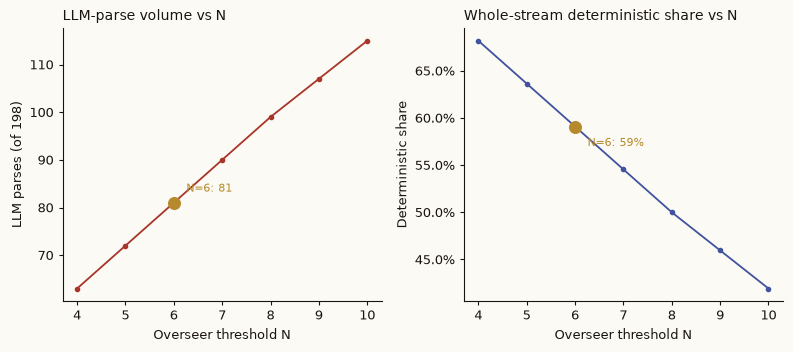

In [23]:
# --- Two side-by-side mini-charts: one measure each, no dual axis -------------------
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(8, 3.6))

chosen_n = 6
chosen_row = sweep[sweep["n"] == chosen_n].iloc[0]

ax_left.plot(sweep["n"], sweep["llm_parses"], color=WINE, lw=1.3, marker="o", markersize=3)
ax_left.scatter([chosen_n], [chosen_row["llm_parses"]], color=GOLD, s=70, zorder=3)
ax_left.annotate(f"N={chosen_n}: {int(chosen_row['llm_parses'])}",
                  xy=(chosen_n, chosen_row["llm_parses"]), xytext=(9, 8),
                  textcoords="offset points", fontsize=8, color=GOLD)
ax_left.set_xlabel("Overseer threshold N")
ax_left.set_ylabel("LLM parses (of 198)")
ax_left.set_title("LLM-parse volume vs N", loc="left")
style_axes(ax_left)

ax_right.plot(sweep["n"], sweep["deterministic_share"], color=INDIGO, lw=1.3, marker="o",
              markersize=3)
ax_right.scatter([chosen_n], [chosen_row["deterministic_share"]], color=GOLD, s=70, zorder=3)
ax_right.annotate(f"N={chosen_n}: {chosen_row['deterministic_share']:.0%}",
                   xy=(chosen_n, chosen_row["deterministic_share"]), xytext=(9, -14),
                   textcoords="offset points", fontsize=8, color=GOLD)
ax_right.set_xlabel("Overseer threshold N")
ax_right.set_ylabel("Deterministic share")
ax_right.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax_right.set_title("Whole-stream deterministic share vs N", loc="left")
style_axes(ax_right)

plt.tight_layout()
plt.show()

Lower N reaches the deterministic state faster, at the cost of trusting a parser after fewer
confirming examples; higher N is more conservative but keeps more documents on the LLM path for
longer, and – for a slow-cadence supplier – risks the re-learning parser never being reborn
before the calendar year runs out. N=6 was chosen because it was the largest threshold that
still kept the LLM-parse volume inside the pre-registered budget across all eight repeat
suppliers; the sweep above is what that trade-off actually looks like on either side of it.

## 10. What transfers

Every deviation in this run's scorecard, planned or not, was visible precisely because the
parsers refuse rather than invent when a document does not match what they were built on –
fail-loud beats silent guessing. Re-learning after a template redesign is not a special
mechanism; it is the same six-consistent-example rule that produced the first generation of
parsers, applied a second time to a new layout. The one class of error that survives every
automated check is the one no document-reading system can catch from the document alone, and
the practical answer is not a better parser but a standard three-way match against what was
actually ordered, run on every parse regardless of how clean it looks. Nor is the answer key
itself exempt from error – first contact between real parses and this run's key surfaced four
ground-truth defects that had nothing to do with the pipeline being tested, the strongest
argument for running exactly this kind of pipeline against any key before trusting it.